In [2]:
# 1. Imports y rutas
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "tables" / "chapter5"
FIGURES_DIR = PROJECT_ROOT / "figures" / "chapter5"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
# 2. Cargar datasets de regímenes (main y robust)

path_main = PROCESSED_DATA_DIR / "dataset_cap4_regimes_full.csv"
path_robust = PROCESSED_DATA_DIR / "dataset_cap4_regimes_full_robust.csv"

df_main = pd.read_csv(path_main, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df_robust = pd.read_csv(path_robust, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

print("df_main shape:", df_main.shape)
print("df_robust shape:", df_robust.shape)

df_main shape: (6631, 10)
df_robust shape: (6631, 10)


In [4]:
# 3-4. Validaciones MAIN

required_cols = ["date", "sample_split_main", "ret_1d", "regime"]
missing_cols_main = [c for c in required_cols if c not in df_main.columns]
if missing_cols_main:
    raise ValueError(f"Faltan columnas en df_main: {missing_cols_main}")

splits_main = set(df_main["sample_split_main"].dropna().unique())
if not {"train", "test"}.issubset(splits_main):
    raise ValueError(f"df_main no contiene train/test. Presentes: {sorted(splits_main)}")

print("Validación MAIN OK")

Validación MAIN OK


In [5]:
# 3-4. Validaciones ROBUST

required_cols_robust = ["date", "sample_split_robust", "ret_1d", "regime"]
missing_cols_robust = [c for c in required_cols_robust if c not in df_robust.columns]
if missing_cols_robust:
    raise ValueError(f"Faltan columnas en df_robust: {missing_cols_robust}")

splits_robust = set(df_robust["sample_split_robust"].dropna().unique())
if not {"train", "test"}.issubset(splits_robust):
    raise ValueError(f"df_robust no contiene train/test. Presentes: {sorted(splits_robust)}")

print("Validación ROBUST OK")

Validación ROBUST OK


In [6]:
# 5-6. Crear y validar df_test MAIN

df_test_main = df_main[df_main["sample_split_main"] == "test"].copy()
df_test_main = df_test_main.sort_values("date").reset_index(drop=True)

print("df_test_main shape:", df_test_main.shape)

if df_test_main.empty:
    raise ValueError("df_test_main está vacío")

df_test_main shape: (1357, 10)


In [7]:
# 5-6. Crear y validar df_test ROBUST

df_test_robust = df_robust[df_robust["sample_split_robust"] == "test"].copy()
df_test_robust = df_test_robust.sort_values("date").reset_index(drop=True)

print("df_test_robust shape:", df_test_robust.shape)

if df_test_robust.empty:
    raise ValueError("df_test_robust está vacío")

df_test_robust shape: (1614, 10)


In [8]:
# 7. Cargar mappings de exposición (main y robust)

mapping_main_path = PROJECT_ROOT / "tables" / "chapter4" / "regime_exposure_mapping.csv"
mapping_robust_path = PROJECT_ROOT / "tables" / "chapter4" / "regime_exposure_mapping_robust.csv"

regime_mapping_main = pd.read_csv(mapping_main_path)
regime_mapping_robust = pd.read_csv(mapping_robust_path)

required_map_cols = ["regime", "economic_label", "risk_order", "target_exposure"]

# Validación MAIN
missing_main = [c for c in required_map_cols if c not in regime_mapping_main.columns]
if missing_main:
    raise ValueError(f"Faltan columnas en mapping MAIN: {missing_main}")

if regime_mapping_main["regime"].duplicated().any():
    raise ValueError("Regímenes duplicados en mapping MAIN")

# Validación ROBUST
missing_robust = [c for c in required_map_cols if c not in regime_mapping_robust.columns]
if missing_robust:
    raise ValueError(f"Faltan columnas en mapping ROBUST: {missing_robust}")

if regime_mapping_robust["regime"].duplicated().any():
    raise ValueError("Regímenes duplicados en mapping ROBUST")


def validate_exposure_mapping(mapping, sample_label):
    if mapping["target_exposure"].isna().any():
        raise ValueError(f"{sample_label}: target_exposure contiene NaN")

    if not mapping["target_exposure"].between(0, 1).all():
        raise ValueError(f"{sample_label}: target_exposure fuera del rango [0, 1]")

    exposure_by_label = mapping.set_index("economic_label")["target_exposure"]
    required_labels = {"low_risk", "medium_risk", "high_risk"}
    missing_labels = required_labels - set(exposure_by_label.index)
    if missing_labels:
        raise ValueError(f"{sample_label}: faltan etiquetas económicas: {missing_labels}")

    low_exposure = exposure_by_label.loc["low_risk"]
    medium_exposure = exposure_by_label.loc["medium_risk"]
    high_exposure = exposure_by_label.loc["high_risk"]

    if not np.isclose(low_exposure, 1.0):
        raise ValueError(f"{sample_label}: low_risk debe tener target_exposure = 1.0")

    if not high_exposure < medium_exposure < low_exposure:
        raise ValueError(
            f"{sample_label}: se esperaba high_risk < medium_risk < low_risk"
        )


validate_exposure_mapping(regime_mapping_main, "MAIN")
validate_exposure_mapping(regime_mapping_robust, "ROBUST")

# Crear diccionarios
regime_exposure_map_main = dict(
    zip(regime_mapping_main["regime"], regime_mapping_main["target_exposure"])
)

regime_exposure_map_robust = dict(
    zip(regime_mapping_robust["regime"], regime_mapping_robust["target_exposure"])
)

print("Mapping MAIN:")
display(regime_mapping_main.sort_values("risk_order"))

print("Mapping ROBUST:")
display(regime_mapping_robust.sort_values("risk_order"))

Mapping MAIN:


,regime,economic_label,risk_order,target_exposure
0,0,low_risk,1,1.00
1,2,medium_risk,2,0.75
2,1,high_risk,3,0.25


Mapping ROBUST:


,regime,economic_label,risk_order,target_exposure
0,0,low_risk,1,1.00
1,1,medium_risk,2,0.75
2,2,high_risk,3,0.25


### Asignación de exposición por régimen

En este paso se traduce la clasificación de regímenes de mercado en una regla operativa de inversión.

Cada régimen identificado por el modelo se asocia a un nivel de exposición al mercado:

- Régimen de bajo riesgo → alta exposición  
- Régimen intermedio → exposición moderada  
- Régimen de estrés → baja exposición  

El objetivo es adaptar dinámicamente la posición de la cartera en función del nivel de riesgo del entorno de mercado.

Dado que las etiquetas numéricas de los regímenes pueden cambiar entre estimaciones (por ejemplo, entre el split principal y el de robustez), es necesario utilizar un mapping explícito que garantice que cada régimen recibe la exposición correcta en cada caso.

Además, se valida que:

- Todos los regímenes presentes en el conjunto de test tienen asignada una exposición  
- No existen valores nulos en la variable `target_exposure`  

Estas comprobaciones son esenciales para evitar errores silenciosos que podrían invalidar el backtest posterior.

In [9]:
# 8-9. Crear target_exposure y validar — MAIN

regimes_test_main = set(df_test_main["regime"].dropna().unique())
regimes_mapped_main = set(regime_mapping_main["regime"].dropna().unique())

missing_main = sorted(regimes_test_main - regimes_mapped_main)
if missing_main:
    raise ValueError(f"MAIN: regímenes sin mapping: {missing_main}")

df_test_main["target_exposure"] = df_test_main["regime"].map(regime_exposure_map_main)

if df_test_main["target_exposure"].isna().any():
    faltantes = sorted(
        df_test_main.loc[df_test_main["target_exposure"].isna(), "regime"].dropna().unique()
    )
    raise ValueError(f"MAIN: target_exposure nulo en regímenes: {faltantes}")

print("target_exposure MAIN OK")


# 8-9. Crear target_exposure y validar — ROBUST

regimes_test_robust = set(df_test_robust["regime"].dropna().unique())
regimes_mapped_robust = set(regime_mapping_robust["regime"].dropna().unique())

missing_robust = sorted(regimes_test_robust - regimes_mapped_robust)
if missing_robust:
    raise ValueError(f"ROBUST: regímenes sin mapping: {missing_robust}")

df_test_robust["target_exposure"] = df_test_robust["regime"].map(regime_exposure_map_robust)

if df_test_robust["target_exposure"].isna().any():
    faltantes = sorted(
        df_test_robust.loc[df_test_robust["target_exposure"].isna(), "regime"].dropna().unique()
    )
    raise ValueError(f"ROBUST: target_exposure nulo en regímenes: {faltantes}")

print("target_exposure ROBUST OK")

target_exposure MAIN OK
target_exposure ROBUST OK


In [10]:
# 10-12. Crear strategy_exposure y validar — MAIN

df_test_main["strategy_exposure"] = df_test_main["target_exposure"].shift(1)
df_test_bt_main = df_test_main.dropna(subset=["strategy_exposure"]).copy()

expected_strategy_exposure_main = df_test_main["target_exposure"].shift(1)
if not df_test_main["strategy_exposure"].equals(expected_strategy_exposure_main):
    raise ValueError("MAIN: strategy_exposure no coincide con target_exposure.shift(1)")

print("df_test_bt_main shape:", df_test_bt_main.shape)

if df_test_bt_main.empty:
    raise ValueError("df_test_bt_main está vacío")


# 10-12. Crear strategy_exposure y validar — ROBUST

df_test_robust["strategy_exposure"] = df_test_robust["target_exposure"].shift(1)
df_test_bt_robust = df_test_robust.dropna(subset=["strategy_exposure"]).copy()

expected_strategy_exposure_robust = df_test_robust["target_exposure"].shift(1)
if not df_test_robust["strategy_exposure"].equals(expected_strategy_exposure_robust):
    raise ValueError("ROBUST: strategy_exposure no coincide con target_exposure.shift(1)")

print("df_test_bt_robust shape:", df_test_bt_robust.shape)

if df_test_bt_robust.empty:
    raise ValueError("df_test_bt_robust está vacío")

df_test_bt_main shape: (1356, 12)
df_test_bt_robust shape: (1613, 12)


In [11]:
# 13. Calcular retornos y acumulados — MAIN

df_test_bt_main["benchmark_return"] = df_test_bt_main["ret_1d"]
df_test_bt_main["strategy_return"] = (
    df_test_bt_main["strategy_exposure"] * df_test_bt_main["ret_1d"]
)

df_test_bt_main["benchmark_cum"] = np.exp(
    df_test_bt_main["benchmark_return"].cumsum()
)
df_test_bt_main["strategy_cum"] = np.exp(
    df_test_bt_main["strategy_return"].cumsum()
)

print("Cálculo retornos MAIN OK")


# 13. Calcular retornos y acumulados — ROBUST

df_test_bt_robust["benchmark_return"] = df_test_bt_robust["ret_1d"]
df_test_bt_robust["strategy_return"] = (
    df_test_bt_robust["strategy_exposure"] * df_test_bt_robust["ret_1d"]
)

df_test_bt_robust["benchmark_cum"] = np.exp(
    df_test_bt_robust["benchmark_return"].cumsum()
)
df_test_bt_robust["strategy_cum"] = np.exp(
    df_test_bt_robust["strategy_return"].cumsum()
)

print("Cálculo retornos ROBUST OK")

Cálculo retornos MAIN OK
Cálculo retornos ROBUST OK


In [12]:
# Funciones auxiliares de métricas

def compute_drawdown(cumulative_returns):
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns / rolling_max) - 1
    return drawdown


def historical_var(returns, alpha=0.05):
    return returns.quantile(alpha)


def historical_cvar(returns, alpha=0.05):
    var = historical_var(returns, alpha)
    return returns[returns <= var].mean()

In [13]:
# 14. Métricas — MAIN

benchmark_drawdown_main = compute_drawdown(df_test_bt_main["benchmark_cum"])
strategy_drawdown_main = compute_drawdown(df_test_bt_main["strategy_cum"])

metrics_test_main = pd.DataFrame(
    {
        "strategy": ["Buy & Hold", "Regime-based"],
        "total_return": [
            df_test_bt_main["benchmark_cum"].iloc[-1] - 1,
            df_test_bt_main["strategy_cum"].iloc[-1] - 1,
        ],
        "mean_daily_return": [
            df_test_bt_main["benchmark_return"].mean(),
            df_test_bt_main["strategy_return"].mean(),
        ],
        "daily_volatility": [
            df_test_bt_main["benchmark_return"].std(),
            df_test_bt_main["strategy_return"].std(),
        ],
        "VaR_95": [
            historical_var(df_test_bt_main["benchmark_return"]),
            historical_var(df_test_bt_main["strategy_return"]),
        ],
        "CVaR_95": [
            historical_cvar(df_test_bt_main["benchmark_return"]),
            historical_cvar(df_test_bt_main["strategy_return"]),
        ],
        "max_drawdown": [
            benchmark_drawdown_main.min(),
            strategy_drawdown_main.min(),
        ],
    }
)

print("Metrics MAIN:")
display(metrics_test_main)


# 14. Métricas — ROBUST

benchmark_drawdown_robust = compute_drawdown(df_test_bt_robust["benchmark_cum"])
strategy_drawdown_robust = compute_drawdown(df_test_bt_robust["strategy_cum"])

metrics_test_robust = pd.DataFrame(
    {
        "strategy": ["Buy & Hold", "Regime-based"],
        "total_return": [
            df_test_bt_robust["benchmark_cum"].iloc[-1] - 1,
            df_test_bt_robust["strategy_cum"].iloc[-1] - 1,
        ],
        "mean_daily_return": [
            df_test_bt_robust["benchmark_return"].mean(),
            df_test_bt_robust["strategy_return"].mean(),
        ],
        "daily_volatility": [
            df_test_bt_robust["benchmark_return"].std(),
            df_test_bt_robust["strategy_return"].std(),
        ],
        "VaR_95": [
            historical_var(df_test_bt_robust["benchmark_return"]),
            historical_var(df_test_bt_robust["strategy_return"]),
        ],
        "CVaR_95": [
            historical_cvar(df_test_bt_robust["benchmark_return"]),
            historical_cvar(df_test_bt_robust["strategy_return"]),
        ],
        "max_drawdown": [
            benchmark_drawdown_robust.min(),
            strategy_drawdown_robust.min(),
        ],
    }
)

print("Metrics ROBUST:")
display(metrics_test_robust)

Metrics MAIN:


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,1.208354,0.000584,0.010256,-0.015875,-0.023772,-0.217647
1,Regime-based,0.895205,0.000471,0.008695,-0.014089,-0.020212,-0.232797


Metrics ROBUST:


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,0.845582,0.000380,0.012730,-0.017642,-0.030660,-0.394343
1,Regime-based,0.689181,0.000325,0.009088,-0.014799,-0.021398,-0.248353


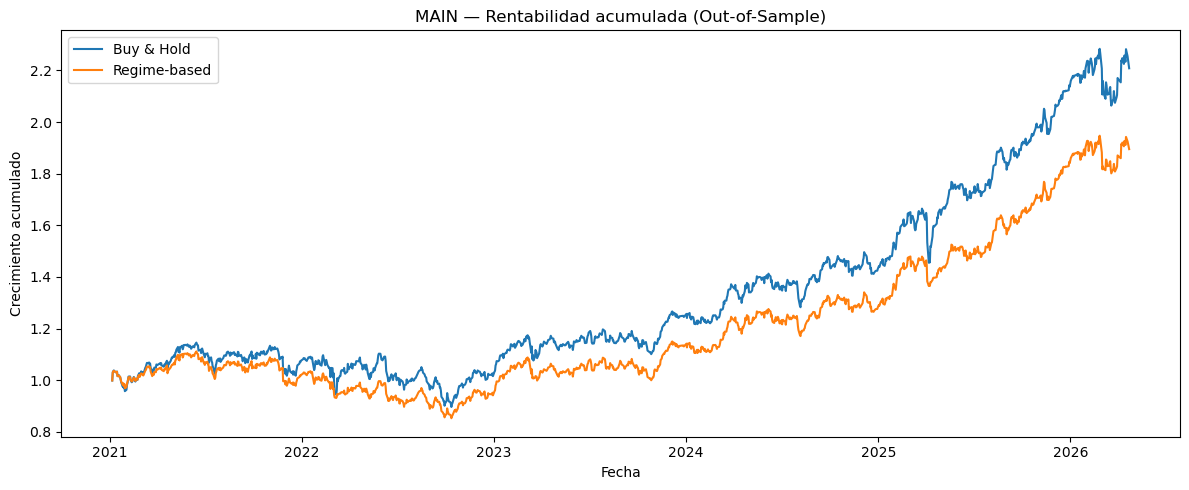

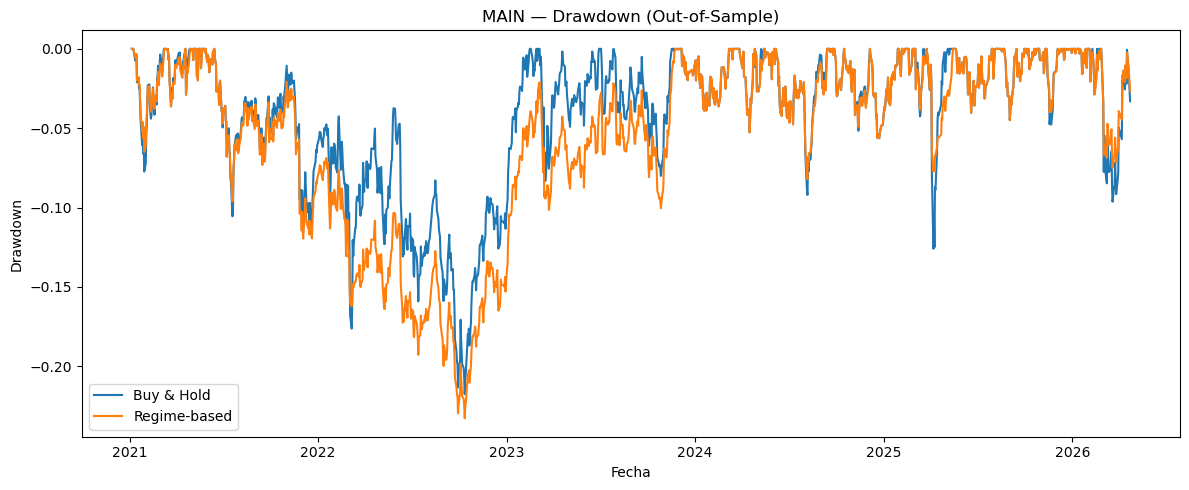

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df_test_bt_main["date"], df_test_bt_main["benchmark_cum"], label="Buy & Hold")
plt.plot(df_test_bt_main["date"], df_test_bt_main["strategy_cum"], label="Regime-based")
plt.title("MAIN — Rentabilidad acumulada (Out-of-Sample)")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento acumulado")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df_test_bt_main["date"], benchmark_drawdown_main, label="Buy & Hold")
plt.plot(df_test_bt_main["date"], strategy_drawdown_main, label="Regime-based")
plt.title("MAIN — Drawdown (Out-of-Sample)")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de sensibilidad: mapping alternativo de exposición

En esta sección se evalúa la sensibilidad de los resultados a la elección del mapping de exposición utilizado en la estrategia basada en regímenes.

En concreto, se compara el mapping original con una alternativa más conservadora, que reduce de forma más agresiva la exposición en los regímenes intermedios y de estrés. El objetivo es analizar si las conclusiones principales del trabajo, especialmente en términos de reducción del riesgo y protección en la cola, se mantienen bajo una configuración distinta pero económicamente razonable.

In [15]:
# Sensitivity analysis: alternative exposure mapping

alternative_exposure_by_risk_order = {
    1: 1.00,  # bajo riesgo
    2: 0.50,  # riesgo intermedio
    3: 0.00,  # estrés
}

# Crear mappings alternativos MAIN y ROBUST respetando la interpretación económica
regime_mapping_main_alt = regime_mapping_main.copy()
regime_mapping_robust_alt = regime_mapping_robust.copy()

regime_mapping_main_alt["target_exposure_alt"] = regime_mapping_main_alt["risk_order"].map(
    alternative_exposure_by_risk_order
)

regime_mapping_robust_alt["target_exposure_alt"] = regime_mapping_robust_alt["risk_order"].map(
    alternative_exposure_by_risk_order
)

# Validación
if regime_mapping_main_alt["target_exposure_alt"].isna().any():
    raise ValueError("MAIN: hay risk_order sin mapping alternativo")

if regime_mapping_robust_alt["target_exposure_alt"].isna().any():
    raise ValueError("ROBUST: hay risk_order sin mapping alternativo")

# Diccionarios régimen -> exposición alternativa
regime_exposure_map_main_alt = dict(
    zip(regime_mapping_main_alt["regime"], regime_mapping_main_alt["target_exposure_alt"])
)

regime_exposure_map_robust_alt = dict(
    zip(regime_mapping_robust_alt["regime"], regime_mapping_robust_alt["target_exposure_alt"])
)

print("Mapping alternativo MAIN:")
display(regime_mapping_main_alt[["regime", "economic_label", "risk_order", "target_exposure", "target_exposure_alt"]].sort_values("risk_order"))

print("Mapping alternativo ROBUST:")
display(regime_mapping_robust_alt[["regime", "economic_label", "risk_order", "target_exposure", "target_exposure_alt"]].sort_values("risk_order"))

Mapping alternativo MAIN:


,regime,economic_label,risk_order,target_exposure,target_exposure_alt
0,0,low_risk,1,1.00,1.0
1,2,medium_risk,2,0.75,0.5
2,1,high_risk,3,0.25,0.0


Mapping alternativo ROBUST:


,regime,economic_label,risk_order,target_exposure,target_exposure_alt
0,0,low_risk,1,1.00,1.0
1,1,medium_risk,2,0.75,0.5
2,2,high_risk,3,0.25,0.0


In [16]:
# Aplicar mapping alternativo — MAIN

df_test_main["target_exposure_alt"] = df_test_main["regime"].map(regime_exposure_map_main_alt)

df_test_main["strategy_exposure_alt"] = df_test_main["target_exposure_alt"].shift(1)

df_test_bt_main_alt = df_test_main.dropna(subset=["strategy_exposure_alt"]).copy()

# Retornos
df_test_bt_main_alt["strategy_return_alt"] = (
    df_test_bt_main_alt["strategy_exposure_alt"] * df_test_bt_main_alt["ret_1d"]
)

# Acumulado (log returns)
df_test_bt_main_alt["strategy_cum_alt"] = np.exp(
    df_test_bt_main_alt["strategy_return_alt"].cumsum()
)

print("MAIN ALT OK:", df_test_bt_main_alt.shape)


# Aplicar mapping alternativo — ROBUST

df_test_robust["target_exposure_alt"] = df_test_robust["regime"].map(regime_exposure_map_robust_alt)

df_test_robust["strategy_exposure_alt"] = df_test_robust["target_exposure_alt"].shift(1)

df_test_bt_robust_alt = df_test_robust.dropna(subset=["strategy_exposure_alt"]).copy()

# Retornos
df_test_bt_robust_alt["strategy_return_alt"] = (
    df_test_bt_robust_alt["strategy_exposure_alt"] * df_test_bt_robust_alt["ret_1d"]
)

# Acumulado
df_test_bt_robust_alt["strategy_cum_alt"] = np.exp(
    df_test_bt_robust_alt["strategy_return_alt"].cumsum()
)

print("ROBUST ALT OK:", df_test_bt_robust_alt.shape)

MAIN ALT OK: (1356, 16)
ROBUST ALT OK: (1613, 16)


In [17]:
def compute_metrics(returns):
    returns = returns.dropna()
    
    total_return = np.exp(returns.sum()) - 1
    mean_return = returns.mean()
    volatility = returns.std()
    
    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()
    
    cumulative = np.exp(returns.cumsum())
    rolling_max = cumulative.cummax()
    drawdown = (cumulative / rolling_max) - 1
    max_drawdown = drawdown.min()
    
    return {
        "total_return": total_return,
        "mean_return": mean_return,
        "volatility": volatility,
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "max_drawdown": max_drawdown,
    }


results_sensitivity = []

# Original mapping
metrics_original = compute_metrics(df_test_bt_main["strategy_return"])

results_sensitivity.append({
    "mapping": "Original (1.0 / 0.75 / 0.25)",
    "strategy": "Regime-based",
    **metrics_original
})

# Alternativo
metrics_alt = compute_metrics(df_test_bt_main_alt["strategy_return_alt"])

results_sensitivity.append({
    "mapping": "Alternative (1.0 / 0.5 / 0.0)",
    "strategy": "Regime-based",
    **metrics_alt
})

df_sensitivity = pd.DataFrame(results_sensitivity)

display(df_sensitivity)

,mapping,strategy,total_return,mean_return,volatility,VaR_95,CVaR_95,max_drawdown
0,Original (1.0 / 0.75 / 0.25),Regime-based,0.895205,0.000471,0.008695,-0.014089,-0.020212,-0.232797
1,Alternative (1.0 / 0.5 / 0.0),Regime-based,0.733915,0.000406,0.007798,-0.012880,-0.018420,-0.220422


In [20]:
# Incorporar columnas alternativas a los outputs principales — MAIN y ROBUST

alt_cols = [
    "date",
    "target_exposure_alt",
    "strategy_exposure_alt",
    "strategy_return_alt",
    "strategy_cum_alt",
]

# MAIN
df_test_bt_main = df_test_bt_main.merge(
    df_test_bt_main_alt[alt_cols],
    on="date",
    how="left",
)

# ROBUST
df_test_bt_robust = df_test_bt_robust.merge(
    df_test_bt_robust_alt[alt_cols],
    on="date",
    how="left",
)

print("Columnas alternativas incorporadas.")
print("MAIN:", [c for c in df_test_bt_main.columns if c.endswith("_alt")])
print("ROBUST:", [c for c in df_test_bt_robust.columns if c.endswith("_alt")])

Columnas alternativas incorporadas.
MAIN: ['target_exposure_alt', 'strategy_exposure_alt', 'strategy_return_alt', 'strategy_cum_alt']
ROBUST: ['target_exposure_alt', 'strategy_exposure_alt', 'strategy_return_alt', 'strategy_cum_alt']


### Interpretación del análisis de sensibilidad

El análisis de sensibilidad muestra que los resultados de la estrategia basada en regímenes son robustos a la elección del mapping de exposición.

La utilización de un mapping más conservador reduce de forma consistente las métricas de riesgo, incluyendo volatilidad, VaR y CVaR, así como el drawdown máximo. Esto confirma que una menor exposición en regímenes adversos mejora la protección frente a eventos extremos.

Sin embargo, esta mejora en términos de riesgo viene acompañada de una reducción en la rentabilidad total, lo que evidencia un claro trade-off entre riesgo y retorno.

En conjunto, estos resultados refuerzan la validez del enfoque propuesto en el TFM, mostrando que la adaptación de la exposición en función del régimen de mercado es eficaz para la gestión del riesgo extremo, independientemente de la especificación concreta del mapping utilizado.

In [21]:
# Exportar análisis de sensibilidad del mapping — Notebook 04

SENSITIVITY_TABLES_DIR = PROJECT_ROOT / "tables" / "chapter6"
SENSITIVITY_TABLES_DIR.mkdir(parents=True, exist_ok=True)

sensitivity_path = SENSITIVITY_TABLES_DIR / "exposure_sensitivity.csv"

df_sensitivity.to_csv(sensitivity_path, index=False)

print("Exportado sensibilidad:", sensitivity_path)

Exportado sensibilidad: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/exposure_sensitivity.csv


In [22]:
# Exportar resultados — MAIN

df_test_bt_main.to_csv(
    PROCESSED_DATA_DIR / "backtest_oos_results.csv",
    index=False,
)

metrics_test_main.to_csv(
    TABLES_DIR / "oos_performance_metrics.csv",
    index=False,
)

print("Exportado MAIN:", PROCESSED_DATA_DIR / "backtest_oos_results.csv")
print("Exportado MAIN:", TABLES_DIR / "oos_performance_metrics.csv")


# Exportar resultados — ROBUST

df_test_bt_robust.to_csv(
    PROCESSED_DATA_DIR / "backtest_oos_results_robust.csv",
    index=False,
)

metrics_test_robust.to_csv(
    TABLES_DIR / "oos_performance_metrics_robust.csv",
    index=False,
)

print("Exportado ROBUST:", PROCESSED_DATA_DIR / "backtest_oos_results_robust.csv")
print("Exportado ROBUST:", TABLES_DIR / "oos_performance_metrics_robust.csv")

Exportado MAIN: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/backtest_oos_results.csv
Exportado MAIN: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter5/oos_performance_metrics.csv
Exportado ROBUST: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/backtest_oos_results_robust.csv
Exportado ROBUST: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter5/oos_performance_metrics_robust.csv
